# Vulcan Materials Revenue Monte Carlo Simulation

Revenue scenario analysis with Monte Carlo simulation, Bull/Base/Bear projections, and risk metrics.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import snowflake.connector
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
conn = snowflake.connector.connect(connection_name=os.getenv('SNOWFLAKE_CONNECTION_NAME') or 'my_snowflake')
print('Connected to Snowflake')

Connected to Snowflake


In [2]:
query = """
SELECT YEAR_MONTH, SUM(SHIPMENT_TONS) as TOTAL_SHIPMENTS,
       SUM(REVENUE_USD) as TOTAL_REVENUE, AVG(PRICE_PER_TON) as AVG_PRICE
FROM VULCAN_MATERIALS_DB.ATOMIC.MONTHLY_SHIPMENTS
WHERE SHIPMENT_TONS > 0 GROUP BY YEAR_MONTH ORDER BY YEAR_MONTH
"""
df = pd.read_sql(query, conn)
df['YEAR_MONTH'] = pd.to_datetime(df['YEAR_MONTH'])
df = df.set_index('YEAR_MONTH')
print(f'Loaded {len(df)} months')
df.head()

Loaded 74 months


,TOTAL_SHIPMENTS,TOTAL_REVENUE,AVG_PRICE
YEAR_MONTH,,,
2020-01-01,32331935.0,7.484765e+08,22.993333
2020-02-01,41223176.0,9.236405e+08,22.669412
2020-03-01,49360056.0,1.087502e+09,22.669412
2020-04-01,64958755.0,1.498856e+09,22.993333
2020-05-01,45846256.0,1.043659e+09,23.052941


In [3]:
class RevenueMonteCarloSimulator:
    def __init__(self, revenue_series):
        self.revenue = revenue_series.dropna()
        self.returns = self.revenue.pct_change().dropna()
        self.mu = self.returns.mean()
        self.sigma = self.returns.std()
        monthly_avg = self.revenue.groupby(self.revenue.index.month).mean()
        self.seasonal_factors = (monthly_avg / monthly_avg.mean()).to_dict()

    def simulate_scenario(self, n_paths, n_months, scenario='base', start_month=1):
        params = {'bull': {'g': 0.02, 'v': 0.8}, 'base': {'g': 0.0, 'v': 1.0}, 'bear': {'g': -0.02, 'v': 1.2}}
        p = params.get(scenario, params['base'])
        mu_adj, sigma_adj = self.mu + p['g'], self.sigma * p['v']
        S0 = self.revenue.iloc[-1]
        paths = np.zeros((n_months + 1, n_paths))
        paths[0] = S0
        for t in range(1, n_months + 1):
            month = ((start_month - 1 + t) % 12) + 1
            seasonal_adj = self.seasonal_factors.get(month, 1.0)
            z = np.random.standard_normal(n_paths)
            paths[t] = paths[t-1] * np.exp((mu_adj - 0.5 * sigma_adj**2) + sigma_adj * z)
            paths[t] = paths[t] * seasonal_adj / np.mean(list(self.seasonal_factors.values()))
        return paths

mc = RevenueMonteCarloSimulator(df['TOTAL_REVENUE'])
np.random.seed(42)
n_paths, n_months = 5000, 24
current_month = df.index[-1].month + 1
bull = mc.simulate_scenario(n_paths, n_months, 'bull', current_month)
base = mc.simulate_scenario(n_paths, n_months, 'base', current_month)
bear = mc.simulate_scenario(n_paths, n_months, 'bear', current_month)
print(f'Simulated {n_paths} paths over {n_months} months')

Simulated 5000 paths over 24 months


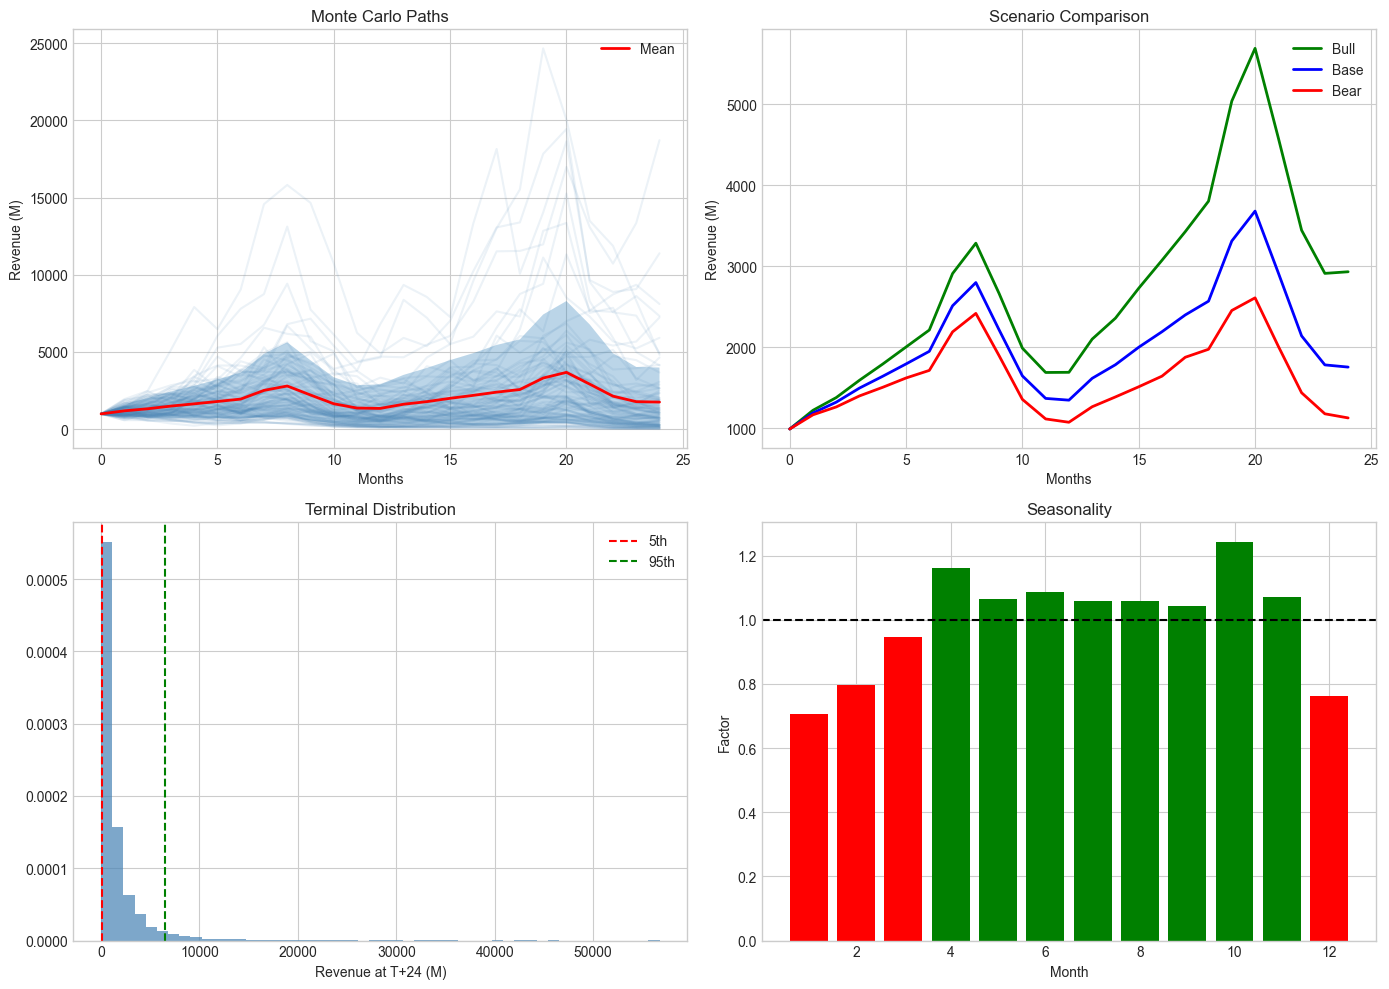

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax = axes[0, 0]
for i in range(100): ax.plot(base[:, i] / 1e6, alpha=0.1, color='steelblue')
ax.plot(base.mean(axis=1) / 1e6, 'r-', lw=2, label='Mean')
ax.fill_between(range(n_months+1), np.percentile(base, 10, axis=1)/1e6, np.percentile(base, 90, axis=1)/1e6, alpha=0.3)
ax.set_xlabel('Months'); ax.set_ylabel('Revenue (M)'); ax.set_title('Monte Carlo Paths'); ax.legend()
ax = axes[0, 1]
ax.plot(bull.mean(axis=1)/1e6, 'g-', lw=2, label='Bull')
ax.plot(base.mean(axis=1)/1e6, 'b-', lw=2, label='Base')
ax.plot(bear.mean(axis=1)/1e6, 'r-', lw=2, label='Bear')
ax.set_xlabel('Months'); ax.set_ylabel('Revenue (M)'); ax.set_title('Scenario Comparison'); ax.legend()
ax = axes[1, 0]
ax.hist(base[-1,:]/1e6, bins=50, alpha=0.7, color='steelblue', density=True)
ax.axvline(np.percentile(base[-1,:], 5)/1e6, color='r', ls='--', label='5th')
ax.axvline(np.percentile(base[-1,:], 95)/1e6, color='g', ls='--', label='95th')
ax.set_xlabel('Revenue at T+24 (M)'); ax.set_title('Terminal Distribution'); ax.legend()
ax = axes[1, 1]
seasonal = df['TOTAL_REVENUE'].groupby(df.index.month).mean()
seasonal = seasonal / seasonal.mean()
colors = ['g' if s > 1 else 'r' for s in seasonal]
ax.bar(range(1,13), seasonal, color=colors)
ax.axhline(1, color='k', ls='--'); ax.set_xlabel('Month'); ax.set_ylabel('Factor'); ax.set_title('Seasonality')
plt.tight_layout(); plt.show()

In [5]:
print('=' * 60)
print('REVENUE MONTE CARLO SUMMARY')
print('=' * 60)
bull_sum = bull.sum(axis=0).mean()/1e6
base_sum = base.sum(axis=0).mean()/1e6
bear_sum = bear.sum(axis=0).mean()/1e6
var_95 = np.percentile(base[:13,:].sum(axis=0), 5)/1e6
print(f'Expected 24M Revenue (Base): ${base_sum:,.1f}M')
print(f'Bull Case: ${bull_sum:,.1f}M')
print(f'Bear Case: ${bear_sum:,.1f}M')
print(f'95 percent VaR (Year 1): ${var_95:,.1f}M')
conn.close()
print('Done')

REVENUE MONTE CARLO SUMMARY
Expected 24M Revenue (Base): $50,409.5M
Bull Case: $67,510.9M
Bear Case: $40,175.4M
95 percent VaR (Year 1): $8,218.9M
Done
